#Ejercicio 3 — BENCHMARK: 3 modelos vs California Housing

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

In [4]:
data = fetch_california_housing(as_frame=True)

X = data.data
y = data.target

In [5]:
print("Primeras filas del DataFrame:")
display(X.head(10))

print("Ultimas filas del DataFrame:")
print(X.tail(5))

print("Informacion del DataFrame:")
print(X.info())

Primeras filas del DataFrame:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25


Ultimas filas del DataFrame:
       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Longitude  
20635    -121.09  
20636    -121.21  
20637    -121.22  
20638    -121.32  
20639    -121.24  
Informacion del DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   P

In [6]:
print("Estadisticas descriptivas del DataFrame:")
print(X.describe())

Estadisticas descriptivas del DataFrame:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude  
count  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704  
std       10.386050      2.135952      2.003532  
min        0.692308     32.540000   -124.350000

In [7]:
print("Tipos originales:")
print(X.dtypes)

Tipos originales:
MedInc        float64
HouseAge      float64
AveRooms      float64
AveBedrms     float64
Population    float64
AveOccup      float64
Latitude      float64
Longitude     float64
dtype: object


In [8]:
n_duplicados = X.duplicated().sum()
print(f"Filas duplicadas: {n_duplicados}")

Filas duplicadas: 0


In [9]:
print("Verificacion de datos nulos:")
print(X.isnull().sum())

Verificacion de datos nulos:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64


**Dividir dataset**

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Escalamiento**

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled =  scaler.transform(X_test)

**Entrenar modelos**

In [12]:
models = {'Regresion Lineal': LinearRegression(), 'KNN Regressor': KNeighborsRegressor(n_neighbors=10), 'Decision Tree': DecisionTreeRegressor(max_depth=8, random_state=42)}
results = []

**Entrenar y Evaluar**

In [13]:
for name, model in models.items():
    if name == 'Decision Tree':
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    else:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    results.append({'Modelo': name, 'R2': r2, 'MAE': mae, 'RMSE': rmse})

**DataFrame resultados**

In [14]:
results_df = pd.DataFrame(results)
print('\nResultados:\n')
print(results_df)


Resultados:

             Modelo        R2       MAE      RMSE
0  Regresion Lineal  0.575788  0.533200  0.745581
1     KNN Regressor  0.678314  0.440338  0.649261
2     Decision Tree  0.677928  0.448169  0.649650


**Barplot**

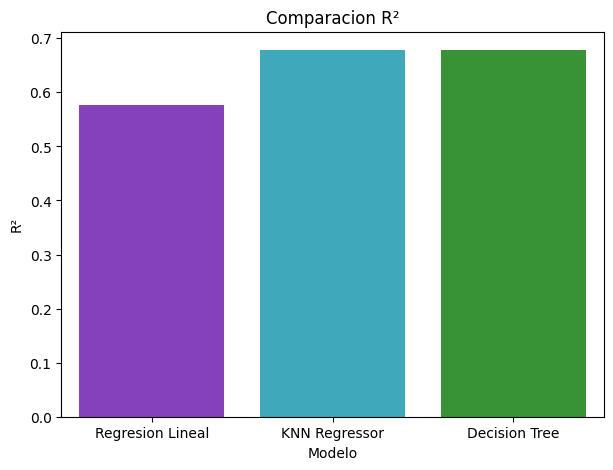

In [17]:
plt.figure(figsize=(7,5))
sns.barplot(data=results_df, x='Modelo', y='R2', hue='Modelo', palette=['#882BCF','#2BB6CF','#29A326'], legend=False)
plt.title('Comparacion R²')
plt.ylabel('R²')
plt.xlabel('Modelo')
plt.show()